In [1]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = str(os.cpu_count() or 4)

# monkeypatch joblib's bundled loky to skip wmic CPU detection on Windows
# _count_physical_cores returns (core_count, exception)
try:
    import joblib.externals.loky.backend.context as _loky_ctx
    _n = os.cpu_count() or 4
    _loky_ctx._count_physical_cores = lambda: (_n, None)
except Exception:
    pass

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GroupKFold, RandomizedSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso, LassoCV, RidgeCV, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor, AdaBoostRegressor)
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.optimize import minimize
import xgboost as xgb
import lightgbm as lgb

RATED_CAPACITY = 2.0  # Ah
BASE = 'NASA_Cleaned_Dataset'
print('Imports done')

Imports done


In [2]:
# load metadata and convert types
meta = pd.read_csv(f'{BASE}/metadata.csv')
meta['Capacity'] = pd.to_numeric(meta['Capacity'], errors='coerce')
meta['Re'] = pd.to_numeric(meta['Re'], errors='coerce')
meta['Rct'] = pd.to_numeric(meta['Rct'], errors='coerce')

# feature extraction from discharge cycles
def extract_cycle_features(meta_df, base_path, battery_id):
    dis = meta_df[(meta_df.battery_id == battery_id) & (meta_df.type == 'discharge') & (meta_df.Capacity.notna())]
    imp = meta_df[(meta_df.battery_id == battery_id) & (meta_df.type == 'impedance')]
    
    features = []
    for idx, (_, row) in enumerate(dis.iterrows()):
        try:
            df = pd.read_csv(f"{base_path}/data/{row['filename']}")
        except:
            continue
        
        v = df['Voltage_measured']
        i = df['Current_measured']
        t = df['Temperature_measured']
        time = df['Time']
        
        feat = {
            'battery_id': battery_id,
            'cycle': idx,
            'capacity': row['Capacity'],
            'v_mean': v.mean(), 'v_std': v.std(), 'v_min': v.min(),
            'v_max': v.max(), 'v_range': v.max() - v.min(),
            'i_mean': i.mean(), 'i_std': i.std(), 'i_min': i.min(), 'i_max': i.max(),
            't_mean': t.mean(), 't_std': t.std(), 't_max': t.max(), 't_rise': t.max() - t.iloc[0],
            'discharge_time': time.max(),
            'energy': np.trapz(v.values * np.abs(i.values), time.values) / 3600,
        }
        
        # impedance from closest prior measurement
        prior_imp = imp[imp.uid < row['uid']]
        if len(prior_imp) > 0:
            last_imp = prior_imp.iloc[-1]
            feat['Re'] = last_imp['Re'] if pd.notna(last_imp['Re']) else np.nan
            feat['Rct'] = last_imp['Rct'] if pd.notna(last_imp['Rct']) else np.nan
        else:
            feat['Re'] = np.nan
            feat['Rct'] = np.nan
        
        features.append(feat)
    return pd.DataFrame(features)

# extract for all batteries, filter bad ones (negative fade = bad initial readings)
all_features = []
for bid in sorted(meta.battery_id.unique()):
    bf = extract_cycle_features(meta, BASE, bid)
    if len(bf) < 10:
        continue
    # skip batteries with clearly bad data (first capacity < 0.5 Ah or negative fade > 20%)
    cap_fade = (bf.capacity.iloc[0] - bf.capacity.iloc[-1]) / bf.capacity.iloc[0] * 100
    if bf.capacity.iloc[0] < 0.5 or cap_fade < -20:
        print(f'  SKIPPED {bid}: cap_start={bf.capacity.iloc[0]:.3f}, fade={cap_fade:.1f}%')
        continue
    all_features.append(bf)
    print(f'{bid}: {len(bf)} cycles, cap {bf.capacity.iloc[0]:.3f} -> {bf.capacity.iloc[-1]:.3f} Ah, fade {cap_fade:.1f}%')

df_all = pd.concat(all_features, ignore_index=True)

# compute SoH target
df_all['SoH'] = df_all['capacity'] / RATED_CAPACITY * 100
print(f'\nTotal samples: {len(df_all)}, Batteries: {df_all.battery_id.nunique()}')
print(f'SoH range: {df_all.SoH.min():.1f}% to {df_all.SoH.max():.1f}%')

B0005: 168 cycles, cap 1.856 -> 1.325 Ah, fade 28.6%
B0006: 168 cycles, cap 2.035 -> 1.186 Ah, fade 41.7%
B0007: 168 cycles, cap 1.891 -> 1.432 Ah, fade 24.3%
B0018: 132 cycles, cap 1.855 -> 1.341 Ah, fade 27.7%
B0025: 28 cycles, cap 1.847 -> 1.768 Ah, fade 4.3%
B0026: 28 cycles, cap 1.813 -> 1.769 Ah, fade 2.5%
B0027: 28 cycles, cap 1.823 -> 1.770 Ah, fade 2.9%
B0028: 28 cycles, cap 1.805 -> 1.717 Ah, fade 4.8%
B0029: 40 cycles, cap 1.698 -> 1.612 Ah, fade 5.0%
B0030: 40 cycles, cap 1.656 -> 1.563 Ah, fade 5.6%
B0031: 40 cycles, cap 1.667 -> 1.667 Ah, fade -0.0%
B0032: 40 cycles, cap 1.705 -> 1.636 Ah, fade 4.1%
  SKIPPED B0033: cap_start=0.068, fade=-1822.2%
  SKIPPED B0034: cap_start=0.746, fade=-71.6%
  SKIPPED B0036: cap_start=1.002, fade=-55.6%
  SKIPPED B0038: cap_start=0.898, fade=-70.4%
  SKIPPED B0039: cap_start=0.119, fade=-1005.0%
B0040: 47 cycles, cap 0.673 -> 0.557 Ah, fade 17.3%
  SKIPPED B0041: cap_start=0.056, fade=-1403.9%
B0042: 112 cycles, cap 1.729 -> 1.337 Ah, fad

In [3]:
# handle missing impedance values - forward fill within each battery
df_all['Re'] = df_all.groupby('battery_id')['Re'].ffill()
df_all['Rct'] = df_all.groupby('battery_id')['Rct'].ffill()
# backfill any remaining NaN at start
df_all['Re'] = df_all.groupby('battery_id')['Re'].bfill()
df_all['Rct'] = df_all.groupby('battery_id')['Rct'].bfill()

# drop any rows still missing
before = len(df_all)
df_all = df_all.dropna(subset=['Re', 'Rct'])
print(f'Dropped {before - len(df_all)} rows with missing impedance')

# feature columns
feature_cols = ['cycle', 'v_mean', 'v_std', 'v_min', 'v_max', 'v_range',
                'i_mean', 'i_std', 'i_min', 'i_max',
                't_mean', 't_std', 't_max', 't_rise',
                'discharge_time', 'energy', 'Re', 'Rct']
target_col = 'SoH'

print(f'Features: {len(feature_cols)}')
print(f'Samples: {len(df_all)}')

# correlation with SoH
corr = df_all[feature_cols + [target_col]].corr()[target_col].drop(target_col).sort_values(key=abs, ascending=False)
print(f'\nTop correlations with SoH:')
for feat, val in corr.items():
    print(f'  {feat:20s}: {val:+.4f}')

Dropped 0 rows with missing impedance
Features: 18
Samples: 1809

Top correlations with SoH:
  energy              : +0.9625
  t_mean              : +0.6235
  t_max               : +0.5964
  v_std               : -0.5505
  discharge_time      : +0.4236
  i_mean              : -0.2553
  v_max               : +0.2158
  t_rise              : +0.1757
  cycle               : -0.1615
  i_std               : -0.1589
  i_min               : +0.1114
  v_mean              : +0.0962
  i_max               : +0.0813
  v_range             : +0.0476
  t_std               : +0.0458
  Re                  : -0.0309
  Rct                 : +0.0305
  v_min               : -0.0202


In [4]:
# train/test split BY BATTERY (prevents data leakage)
# use classic 4 cells as test set (most well-studied), rest for training
classic = ['B0005', 'B0006', 'B0007', 'B0018']
train_batteries = [b for b in df_all.battery_id.unique() if b not in classic]
test_batteries = classic

train_df = df_all[df_all.battery_id.isin(train_batteries)].copy()
test_df = df_all[df_all.battery_id.isin(test_batteries)].copy()

X_train = train_df[feature_cols].values
y_train = train_df[target_col].values
X_test = test_df[feature_cols].values
y_test = test_df[target_col].values
groups_train = train_df['battery_id'].values

# scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Train: {len(train_df)} samples from {train_df.battery_id.nunique()} batteries: {sorted(train_batteries)}')
print(f'Test:  {len(test_df)} samples from {test_df.battery_id.nunique()} batteries: {test_batteries}')
print(f'\nTrain SoH: {y_train.min():.1f}% to {y_train.max():.1f}%')
print(f'Test SoH:  {y_test.min():.1f}% to {y_test.max():.1f}%')

Train: 1173 samples from 21 batteries: ['B0025', 'B0026', 'B0027', 'B0028', 'B0029', 'B0030', 'B0031', 'B0032', 'B0040', 'B0042', 'B0043', 'B0044', 'B0045', 'B0046', 'B0047', 'B0048', 'B0049', 'B0050', 'B0051', 'B0053', 'B0054']
Test:  636 samples from 4 batteries: ['B0005', 'B0006', 'B0007', 'B0018']

Train SoH: 0.0% to 132.0%
Test SoH:  57.7% to 101.8%


In [5]:
# ============================================================
# ROUND 1: Baseline Models
# ============================================================
r1_models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'SVR': SVR(kernel='rbf', C=10),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'Extra Trees': ExtraTreesRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=200, random_state=42),
    'MLP': MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42),
}

results = {}
r1_preds = {}

for name, model in r1_models.items():
    model.fit(X_train_s, y_train)
    y_pred_train = model.predict(X_train_s)
    y_pred_test = model.predict(X_test_s)
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    results[name] = {
        'Round': 'R1', 'R2_train': r2_train, 'R2_test': r2_test,
        'MAE': mae_test, 'RMSE': rmse_test, 'Overfit': r2_train - r2_test
    }
    r1_preds[name] = y_pred_test
    print(f'{name:25s} | R2: {r2_test:.4f} | MAE: {mae_test:.2f}% | RMSE: {rmse_test:.2f}%')

# find R1 best
r1_best = max(results, key=lambda k: results[k]['R2_test'])
print(f'\nR1 Best: {r1_best} (R2={results[r1_best]["R2_test"]:.4f})')

Ridge                     | R2: 0.8970 | MAE: 2.75% | RMSE: 3.19%
Lasso                     | R2: 0.8706 | MAE: 3.00% | RMSE: 3.57%
KNN                       | R2: -0.1957 | MAE: 8.36% | RMSE: 10.86%
SVR                       | R2: 0.2785 | MAE: 7.47% | RMSE: 8.43%
Random Forest             | R2: 0.8393 | MAE: 2.88% | RMSE: 3.98%
Extra Trees               | R2: 0.9085 | MAE: 2.10% | RMSE: 3.00%
Gradient Boosting         | R2: 0.9355 | MAE: 1.72% | RMSE: 2.52%
AdaBoost                  | R2: 0.8311 | MAE: 3.34% | RMSE: 4.08%
MLP                       | R2: 0.8217 | MAE: 3.46% | RMSE: 4.19%

R1 Best: Gradient Boosting (R2=0.9355)


In [6]:
# ============================================================
# ROUND 2: Hyperparameter Tuning (XGBoost + LightGBM) + Ensemble
# ============================================================
gkf = GroupKFold(n_splits=min(5, len(np.unique(groups_train))))

# XGBoost tuning
xgb_params = {
    'n_estimators': [100, 200, 500, 800],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0],
}

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0),
    xgb_params, n_iter=100, cv=gkf, scoring='r2',
    random_state=42, n_jobs=-1
)
xgb_search.fit(X_train_s, y_train, groups=groups_train)
xgb_best = xgb_search.best_estimator_

y_pred_xgb = xgb_best.predict(X_test_s)
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

results['XGBoost (tuned)'] = {
    'Round': 'R2', 'R2_train': r2_score(y_train, xgb_best.predict(X_train_s)),
    'R2_test': r2_xgb, 'MAE': mae_xgb, 'RMSE': rmse_xgb,
    'Overfit': r2_score(y_train, xgb_best.predict(X_train_s)) - r2_xgb
}
r1_preds['XGBoost (tuned)'] = y_pred_xgb
print(f'XGBoost (tuned)           | R2: {r2_xgb:.4f} | MAE: {mae_xgb:.2f}% | RMSE: {rmse_xgb:.2f}%')
print(f'  Best params: {xgb_search.best_params_}')

XGBoost (tuned)           | R2: 0.8984 | MAE: 2.46% | RMSE: 3.17%
  Best params: {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.6}


In [7]:
# LightGBM tuning
lgb_params = {
    'n_estimators': [100, 200, 500, 800],
    'max_depth': [3, 5, 7, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [15, 31, 63, 127],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_samples': [5, 10, 20],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0],
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=42, verbosity=-1),
    lgb_params, n_iter=100, cv=gkf, scoring='r2',
    random_state=42, n_jobs=-1
)
lgb_search.fit(X_train_s, y_train, groups=groups_train)
lgb_best = lgb_search.best_estimator_

y_pred_lgb = lgb_best.predict(X_test_s)
r2_lgb = r2_score(y_test, y_pred_lgb)
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))

results['LightGBM (tuned)'] = {
    'Round': 'R2', 'R2_train': r2_score(y_train, lgb_best.predict(X_train_s)),
    'R2_test': r2_lgb, 'MAE': mae_lgb, 'RMSE': rmse_lgb,
    'Overfit': r2_score(y_train, lgb_best.predict(X_train_s)) - r2_lgb
}
r1_preds['LightGBM (tuned)'] = y_pred_lgb
print(f'LightGBM (tuned)          | R2: {r2_lgb:.4f} | MAE: {mae_lgb:.2f}% | RMSE: {rmse_lgb:.2f}%')
print(f'  Best params: {lgb_search.best_params_}')

LightGBM (tuned)          | R2: 0.8811 | MAE: 2.38% | RMSE: 3.42%
  Best params: {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 1.0, 'num_leaves': 15, 'n_estimators': 200, 'min_child_samples': 5, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}


In [8]:
# R2 Ensemble: weighted average of R1 best + XGBoost + LightGBM
r1_best_model = r1_models[r1_best]

# OOF predictions for weight optimization
oof_r1 = cross_val_predict(r1_best_model, X_train_s, y_train, cv=gkf, groups=groups_train)
oof_xgb = cross_val_predict(xgb_best, X_train_s, y_train, cv=gkf, groups=groups_train)
oof_lgb = cross_val_predict(lgb_best, X_train_s, y_train, cv=gkf, groups=groups_train)

oof_stack = np.column_stack([oof_r1, oof_xgb, oof_lgb])
test_stack = np.column_stack([r1_preds[r1_best], y_pred_xgb, y_pred_lgb])

# optimize weights
def ensemble_loss(w):
    pred = oof_stack @ w
    return mean_squared_error(y_train, pred)

res = minimize(ensemble_loss, x0=[1/3, 1/3, 1/3],
               constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
               bounds=[(0, 1)] * 3, method='SLSQP')
w_opt = res.x
print(f'Optimal weights: {r1_best}={w_opt[0]:.3f}, XGBoost={w_opt[1]:.3f}, LightGBM={w_opt[2]:.3f}')

y_pred_ens = test_stack @ w_opt
r2_ens = r2_score(y_test, y_pred_ens)
mae_ens = mean_absolute_error(y_test, y_pred_ens)
rmse_ens = np.sqrt(mean_squared_error(y_test, y_pred_ens))

results['Weighted Ensemble'] = {
    'Round': 'R2', 'R2_train': r2_score(y_train, oof_stack @ w_opt),
    'R2_test': r2_ens, 'MAE': mae_ens, 'RMSE': rmse_ens,
    'Overfit': r2_score(y_train, oof_stack @ w_opt) - r2_ens
}
r1_preds['Weighted Ensemble'] = y_pred_ens
print(f'Weighted Ensemble         | R2: {r2_ens:.4f} | MAE: {mae_ens:.2f}% | RMSE: {rmse_ens:.2f}%')

# simple average too
y_pred_avg = test_stack.mean(axis=1)
r2_avg = r2_score(y_test, y_pred_avg)
mae_avg = mean_absolute_error(y_test, y_pred_avg)
rmse_avg = np.sqrt(mean_squared_error(y_test, y_pred_avg))
results['Simple Average'] = {
    'Round': 'R2', 'R2_train': r2_score(y_train, oof_stack.mean(axis=1)),
    'R2_test': r2_avg, 'MAE': mae_avg, 'RMSE': rmse_avg,
    'Overfit': r2_score(y_train, oof_stack.mean(axis=1)) - r2_avg
}
r1_preds['Simple Average'] = y_pred_avg
print(f'Simple Average            | R2: {r2_avg:.4f} | MAE: {mae_avg:.2f}% | RMSE: {rmse_avg:.2f}%')

Optimal weights: Gradient Boosting=0.095, XGBoost=0.617, LightGBM=0.288
Weighted Ensemble         | R2: 0.9468 | MAE: 1.74% | RMSE: 2.29%
Simple Average            | R2: 0.9610 | MAE: 1.32% | RMSE: 1.96%


In [9]:
# ============================================================
# ROUND 3: Polynomial Features + Stacking
# ============================================================
# select top 10 features by correlation
top_feats = corr.abs().sort_values(ascending=False).head(10).index.tolist()
print(f'Top 10 features for poly: {top_feats}')

top_idx = [feature_cols.index(f) for f in top_feats]
X_train_top = X_train_s[:, top_idx]
X_test_top = X_test_s[:, top_idx]

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_train_poly = poly.fit_transform(X_train_top)
X_test_poly = poly.transform(X_test_top)
print(f'Polynomial features: {X_train_poly.shape[1]}')

# precompute CV splits (LassoCV doesn't accept groups kwarg)
cv_splits = list(gkf.split(X_train_poly, y_train, groups=groups_train))

# LassoCV on poly features
alphas = np.logspace(-4, 2, 50)
lasso_cv = LassoCV(alphas=alphas, cv=cv_splits, max_iter=10000)
lasso_cv.fit(X_train_poly, y_train)
y_pred_lasso = lasso_cv.predict(X_test_poly)
r2_lasso = r2_score(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
results['LassoCV (poly)'] = {
    'Round': 'R3', 'R2_train': r2_score(y_train, lasso_cv.predict(X_train_poly)),
    'R2_test': r2_lasso, 'MAE': mae_lasso, 'RMSE': rmse_lasso,
    'Overfit': r2_score(y_train, lasso_cv.predict(X_train_poly)) - r2_lasso
}
r1_preds['LassoCV (poly)'] = y_pred_lasso
print(f'LassoCV (poly)            | R2: {r2_lasso:.4f} | MAE: {mae_lasso:.2f}% | RMSE: {rmse_lasso:.2f}% | alpha={lasso_cv.alpha_:.4f}')

# RidgeCV on poly features
ridge_cv = RidgeCV(alphas=alphas, cv=None)  # uses efficient LOO
ridge_cv.fit(X_train_poly, y_train)
y_pred_ridge = ridge_cv.predict(X_test_poly)
r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
results['RidgeCV (poly)'] = {
    'Round': 'R3', 'R2_train': r2_score(y_train, ridge_cv.predict(X_train_poly)),
    'R2_test': r2_ridge, 'MAE': mae_ridge, 'RMSE': rmse_ridge,
    'Overfit': r2_score(y_train, ridge_cv.predict(X_train_poly)) - r2_ridge
}
r1_preds['RidgeCV (poly)'] = y_pred_ridge
print(f'RidgeCV (poly)            | R2: {r2_ridge:.4f} | MAE: {mae_ridge:.2f}% | RMSE: {rmse_ridge:.2f}% | alpha={ridge_cv.alpha_:.4f}')

# ElasticNet stacking meta-learner on Lasso + Ridge poly predictions
meta_train = np.column_stack([lasso_cv.predict(X_train_poly), ridge_cv.predict(X_train_poly)])
meta_test = np.column_stack([y_pred_lasso, y_pred_ridge])
en_stack = ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000)
en_stack.fit(meta_train, y_train)
y_pred_stack = en_stack.predict(meta_test)
r2_stack = r2_score(y_test, y_pred_stack)
mae_stack = mean_absolute_error(y_test, y_pred_stack)
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))
results['ElasticNet Stack'] = {
    'Round': 'R3', 'R2_train': r2_score(y_train, en_stack.predict(meta_train)),
    'R2_test': r2_stack, 'MAE': mae_stack, 'RMSE': rmse_stack,
    'Overfit': r2_score(y_train, en_stack.predict(meta_train)) - r2_stack
}
r1_preds['ElasticNet Stack'] = y_pred_stack
print(f'ElasticNet Stack          | R2: {r2_stack:.4f} | MAE: {mae_stack:.2f}% | RMSE: {rmse_stack:.2f}%')

Top 10 features for poly: ['energy', 't_mean', 't_max', 'v_std', 'discharge_time', 'i_mean', 'v_max', 't_rise', 'cycle', 'i_std']
Polynomial features: 65
LassoCV (poly)            | R2: 0.9588 | MAE: 1.66% | RMSE: 2.02% | alpha=0.6251
RidgeCV (poly)            | R2: -2.9080 | MAE: 18.85% | RMSE: 19.63% | alpha=0.0001
ElasticNet Stack          | R2: -2.9022 | MAE: 18.84% | RMSE: 19.62%


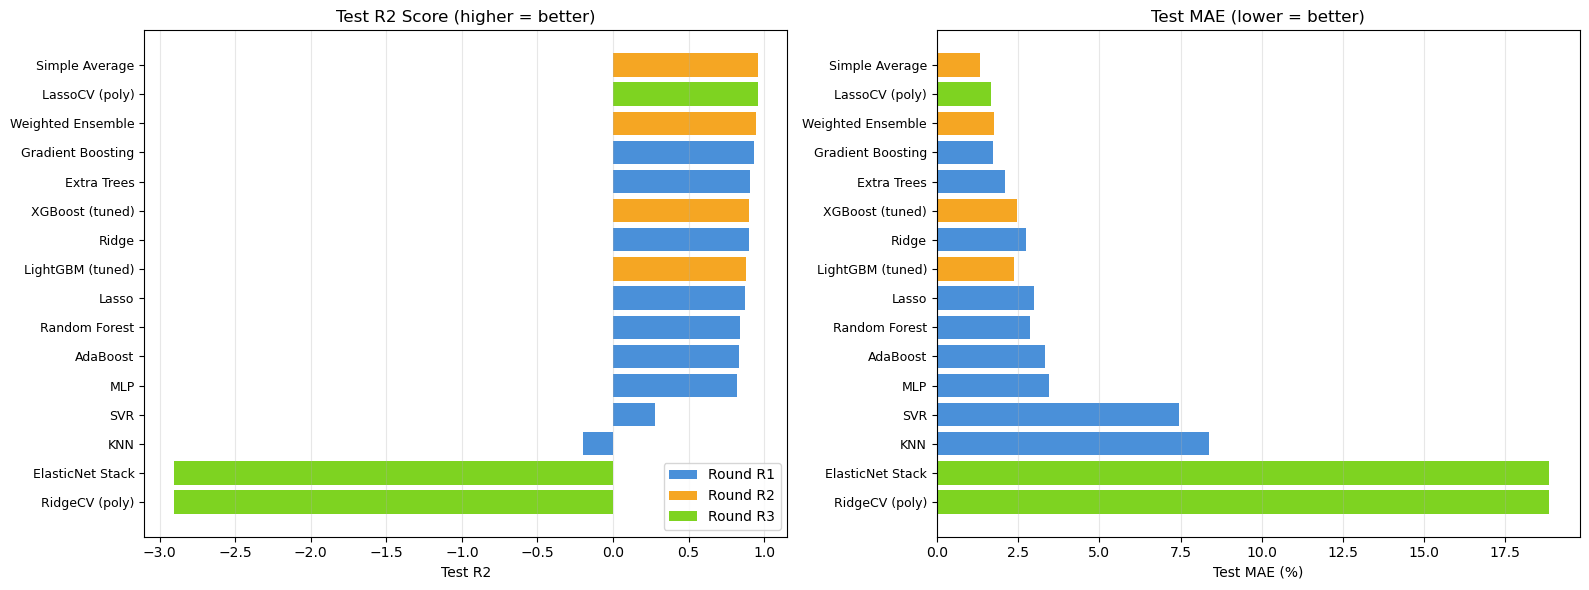

                  Round   R2_test        MAE       RMSE   Overfit
Model                                                            
Simple Average       R2  0.960966   1.321641   1.961965 -0.022243
LassoCV (poly)       R3  0.958763   1.659905    2.01657  0.003837
Weighted Ensemble    R2  0.946817   1.744154   2.290099 -0.004879
Gradient Boosting    R1  0.935517    1.71643   2.521678  0.064243
Extra Trees          R1  0.908531   2.100366   3.003344  0.091469
XGBoost (tuned)      R2  0.898371   2.461867   3.165751  0.101604
Ridge                R1  0.896951    2.74828   3.187783  0.060909
LightGBM (tuned)     R2  0.881098   2.381918   3.424223  0.117235
Lasso                R1    0.8706   2.999904   3.572186  0.084432
Random Forest        R1   0.83929   2.876498   3.980976  0.159212
AdaBoost             R1  0.831132   3.338275   4.080765  0.159818
MLP                  R1  0.821698   3.463683   4.193198  0.178076
SVR                  R1  0.278508   7.465907   8.434963  0.693775
KNN       

In [10]:
# ============================================================
# RESULTS COMPARISON
# ============================================================
res_df = pd.DataFrame(results).T
res_df.index.name = 'Model'
res_df = res_df.sort_values('R2_test', ascending=False)

# color by round
round_colors = {'R1': '#4A90D9', 'R2': '#F5A623', 'R3': '#7ED321'}
colors = [round_colors[r] for r in res_df['Round']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(range(len(res_df)), res_df['R2_test'], color=colors)
axes[0].set_yticks(range(len(res_df)))
axes[0].set_yticklabels(res_df.index, fontsize=9)
axes[0].set_xlabel('Test R2')
axes[0].set_title('Test R2 Score (higher = better)')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(range(len(res_df)), res_df['MAE'], color=colors)
axes[1].set_yticks(range(len(res_df)))
axes[1].set_yticklabels(res_df.index, fontsize=9)
axes[1].set_xlabel('Test MAE (%)')
axes[1].set_title('Test MAE (lower = better)')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

# legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=f'Round {r}') for r, c in round_colors.items()]
axes[0].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print(res_df[['Round', 'R2_test', 'MAE', 'RMSE', 'Overfit']].to_string())

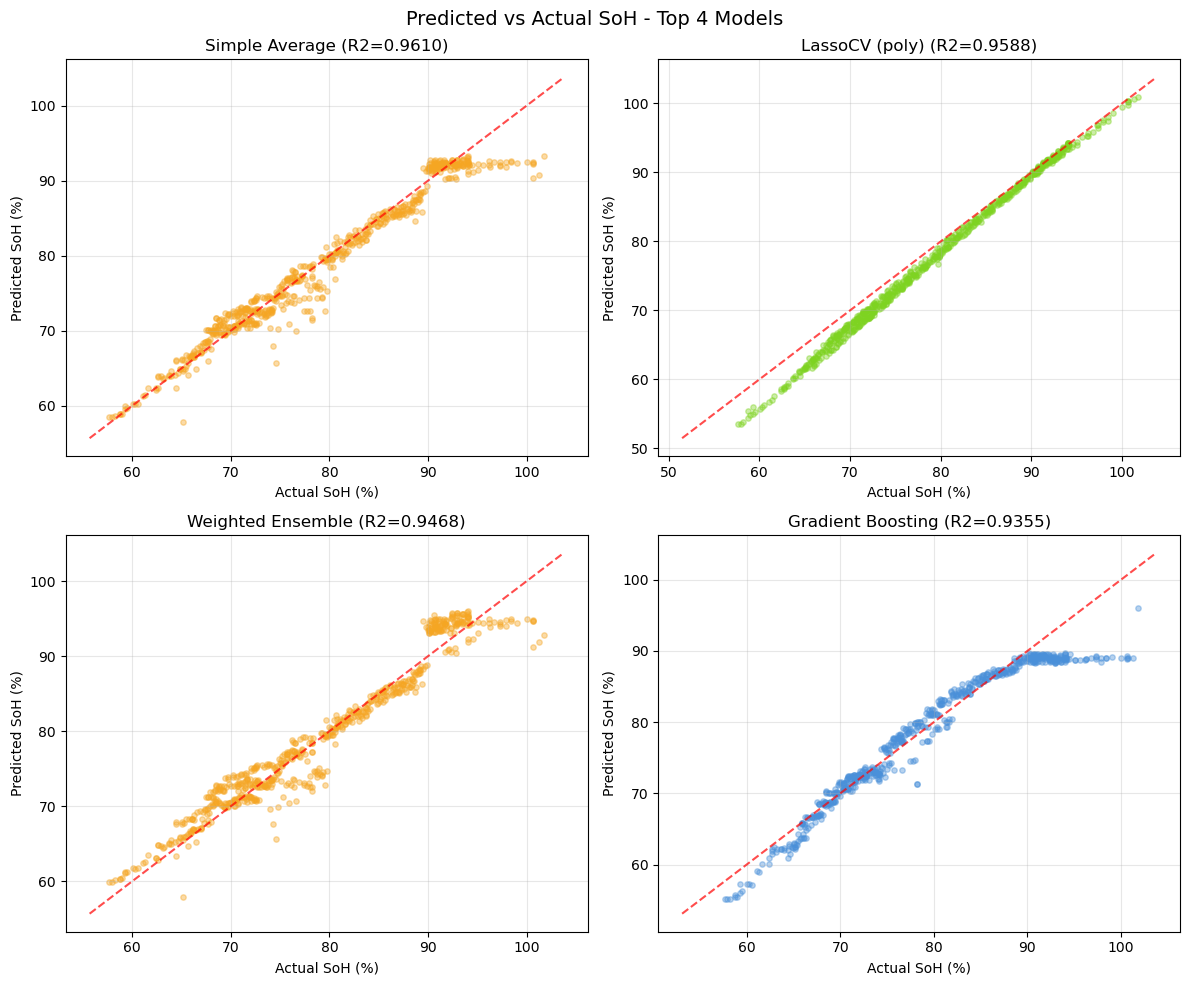

In [11]:
# scatter: predicted vs actual for top 4 models
top4 = res_df.index[:4].tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, name in zip(axes.flat, top4):
    pred = r1_preds[name]
    ax.scatter(y_test, pred, alpha=0.4, s=15, c=round_colors[results[name]['Round']])
    mn, mx = min(y_test.min(), pred.min()) - 2, max(y_test.max(), pred.max()) + 2
    ax.plot([mn, mx], [mn, mx], 'r--', alpha=0.7)
    ax.set_xlabel('Actual SoH (%)')
    ax.set_ylabel('Predicted SoH (%)')
    ax.set_title(f'{name} (R2={results[name]["R2_test"]:.4f})')
    ax.grid(True, alpha=0.3)
plt.suptitle('Predicted vs Actual SoH - Top 4 Models', fontsize=14)
plt.tight_layout()
plt.show()

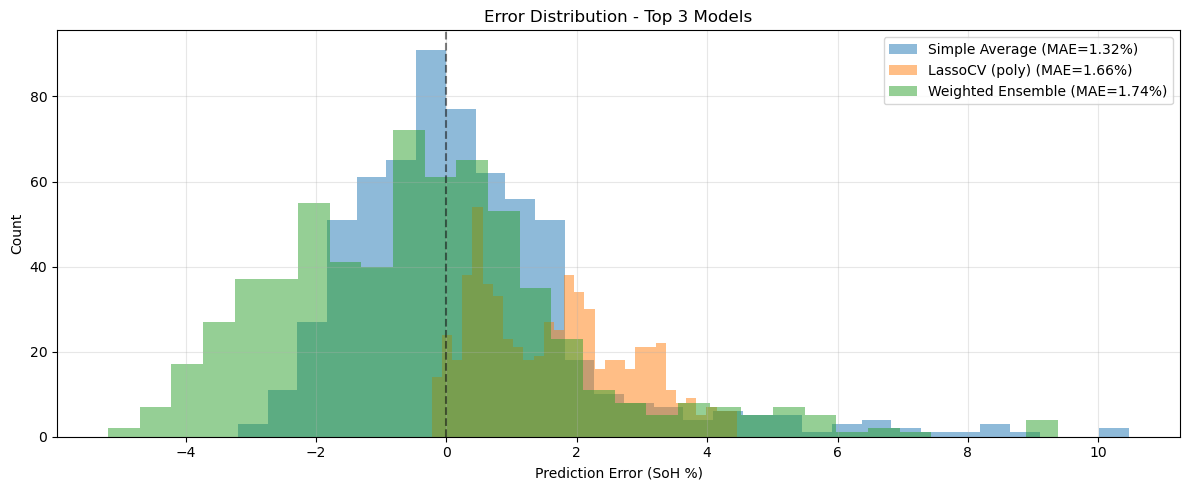

In [12]:
# error distribution for top 3 models
top3 = res_df.index[:3].tolist()
fig, ax = plt.subplots(figsize=(12, 5))
for name in top3:
    errors = y_test - r1_preds[name]
    ax.hist(errors, bins=30, alpha=0.5, label=f'{name} (MAE={results[name]["MAE"]:.2f}%)')
ax.set_xlabel('Prediction Error (SoH %)')
ax.set_ylabel('Count')
ax.set_title('Error Distribution - Top 3 Models')
ax.legend()
ax.axvline(x=0, color='k', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

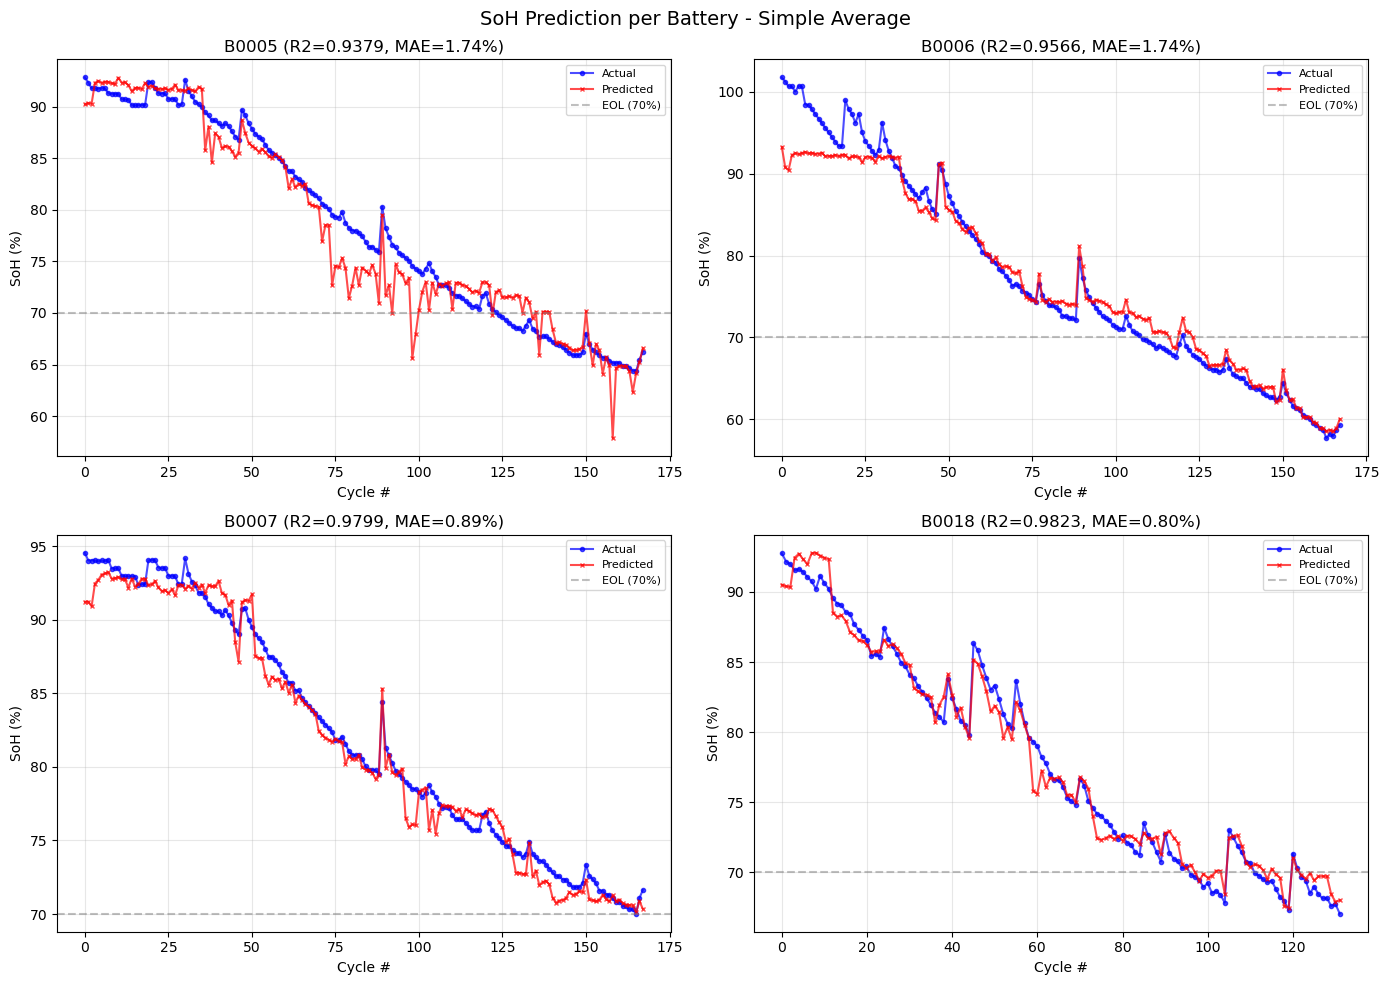

In [13]:
# SoH prediction over cycles for each test battery
best_model_name = res_df.index[0]
best_preds = r1_preds[best_model_name]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, bid in zip(axes.flat, classic):
    mask = test_df.battery_id == bid
    cycles = test_df.loc[mask, 'cycle'].values
    actual = test_df.loc[mask, 'SoH'].values
    predicted = best_preds[mask.values]
    
    ax.plot(cycles, actual, 'b-o', markersize=3, label='Actual', alpha=0.7)
    ax.plot(cycles, predicted, 'r-x', markersize=3, label='Predicted', alpha=0.7)
    ax.axhline(y=70, color='gray', linestyle='--', alpha=0.5, label='EOL (70%)')
    ax.set_xlabel('Cycle #')
    ax.set_ylabel('SoH (%)')
    r2_bid = r2_score(actual, predicted)
    mae_bid = mean_absolute_error(actual, predicted)
    ax.set_title(f'{bid} (R2={r2_bid:.4f}, MAE={mae_bid:.2f}%)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'SoH Prediction per Battery - {best_model_name}', fontsize=14)
plt.tight_layout()
plt.show()

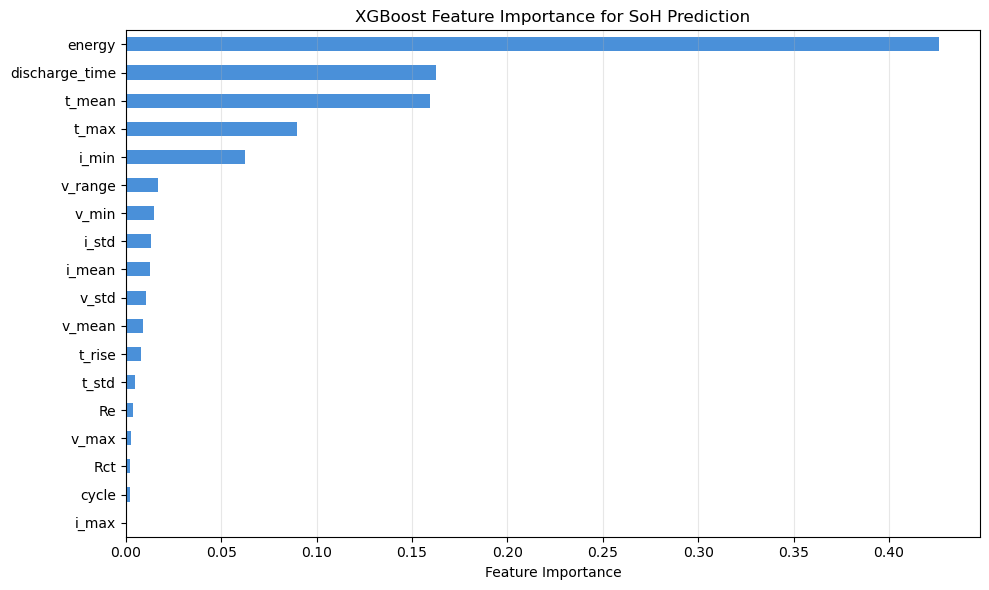

Top 5 features:
  energy              : 0.4264
  discharge_time      : 0.1624
  t_mean              : 0.1593
  t_max               : 0.0896
  i_min               : 0.0625


In [14]:
# feature importance (from best tree-based model)
# use XGBoost feature importance
importances = xgb_best.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.plot(kind='barh', ax=ax, color='#4A90D9')
ax.set_xlabel('Feature Importance')
ax.set_title('XGBoost Feature Importance for SoH Prediction')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('Top 5 features:')
for feat, imp in feat_imp.sort_values(ascending=False).head(5).items():
    print(f'  {feat:20s}: {imp:.4f}')

In [15]:
# final summary
print('=' * 80)
print('SoH PREDICTION BENCHMARK - FINAL RESULTS')
print('=' * 80)
print(f'Dataset: NASA Battery ({df_all.battery_id.nunique()} batteries, {len(df_all)} cycles)')
print(f'Train: {len(train_df)} samples ({train_df.battery_id.nunique()} batteries)')
print(f'Test:  {len(test_df)} samples ({test_df.battery_id.nunique()} batteries: {classic})')
print(f'Features: {len(feature_cols)}')
print(f'Target: SoH (%) = Capacity / {RATED_CAPACITY} Ah * 100')
print()
print(f'{"Model":30s} {"Round":5s} {"R2":>8s} {"MAE":>8s} {"RMSE":>8s} {"Overfit":>8s}')
print('-' * 80)
for name, row in res_df.iterrows():
    print(f'{name:30s} {row["Round"]:5s} {row["R2_test"]:8.4f} {row["MAE"]:7.2f}% {row["RMSE"]:7.2f}% {row["Overfit"]:+8.4f}')
print('-' * 80)
best = res_df.index[0]
print(f'\nBEST MODEL: {best}')
print(f'  R2: {results[best]["R2_test"]:.4f} | MAE: {results[best]["MAE"]:.2f}% | RMSE: {results[best]["RMSE"]:.2f}%')

SoH PREDICTION BENCHMARK - FINAL RESULTS
Dataset: NASA Battery (25 batteries, 1809 cycles)
Train: 1173 samples (21 batteries)
Test:  636 samples (4 batteries: ['B0005', 'B0006', 'B0007', 'B0018'])
Features: 18
Target: SoH (%) = Capacity / 2.0 Ah * 100

Model                          Round       R2      MAE     RMSE  Overfit
--------------------------------------------------------------------------------
Simple Average                 R2      0.9610    1.32%    1.96%  -0.0222
LassoCV (poly)                 R3      0.9588    1.66%    2.02%  +0.0038
Weighted Ensemble              R2      0.9468    1.74%    2.29%  -0.0049
Gradient Boosting              R1      0.9355    1.72%    2.52%  +0.0642
Extra Trees                    R1      0.9085    2.10%    3.00%  +0.0915
XGBoost (tuned)                R2      0.8984    2.46%    3.17%  +0.1016
Ridge                          R1      0.8970    2.75%    3.19%  +0.0609
LightGBM (tuned)               R2      0.8811    2.38%    3.42%  +0.1172
Lasso    